In [136]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding
Thesis plot settings applied


C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\2812399410.py:18: UserWarning: The following kwargs were not used by contour: 'aspect'
  ax[0].contourf(z_nd, r_nd, u[750,:,:], cmap = 'bwr', norm = norm, aspect = 'fixed')


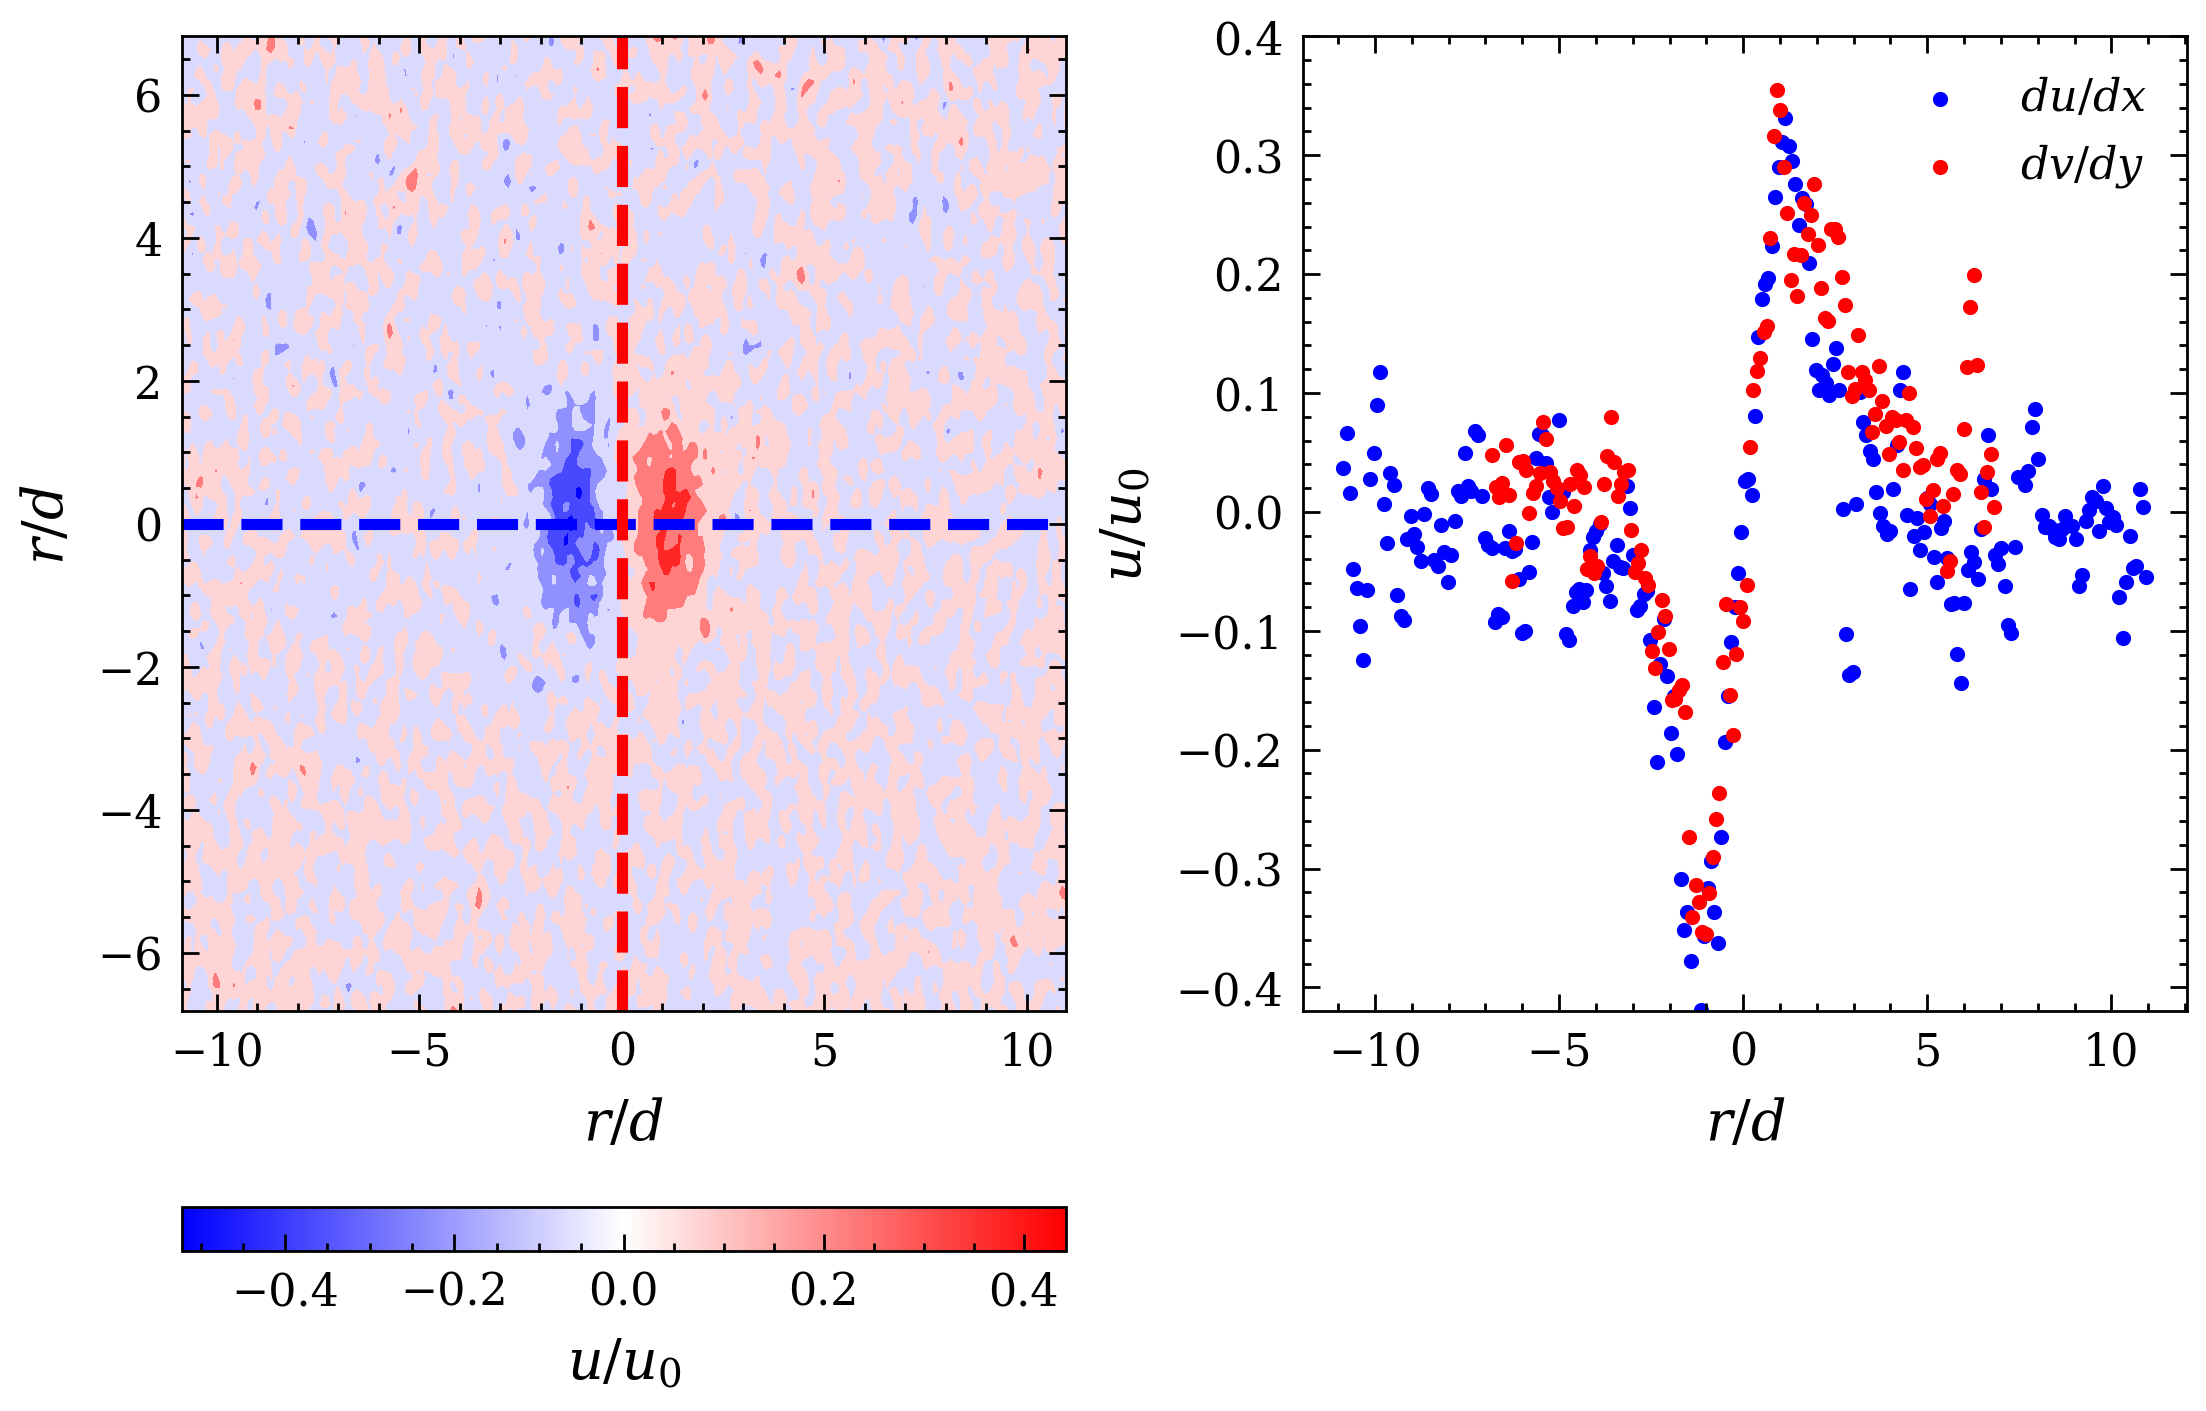

In [137]:
h5file = h5py.File('E:/H5/3D0HLSFine.h5', 'r')



vels = h5file['3D0']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])
frames0 = [750, 1020, 1470]

# u, v = gaussian_filter(u, 1), gaussian_filter(v, 1)

x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])

norm = colors.TwoSlopeNorm(vmin=np.min(u[750,:,:]), vcenter=0, vmax=np.max(u[750,:,:]))
fig, ax = plt.subplots(1, 2,figsize=(5.5, 3.5), dpi = 400)
ax[0].contourf(z_nd, r_nd, u[750,:,:], cmap = 'bwr', norm = norm, aspect = 'fixed')
ax[0].hlines(y=0, xmin=z_nd[0], xmax=z_nd[-1], color='b', linestyle='--', )
ax[0].vlines(x=0, ymin=r_nd[0], ymax=r_nd[-1], color='r', linestyle='--', )
ax[0].set_xlabel('$r/d$')
ax[0].set_ylabel('$r/d$')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax[0], label=r'$u/u_{0}$', location='bottom')
ax[1].scatter(z_nd, u[750, int(u.shape[1]/2), :], label=r'$du/dx$', s=3, color='b')
ax[1].scatter(r_nd, v[750, :, int(u.shape[2]/2)], label=r'$dv/dy$', s=3, color='r')
ax[1].set_xlabel('$r/d$')
ax[1].set_ylabel(r'$u/u_{0}$')
ax[1].set_ylim(-0.42, 0.4)
plt.legend(fontsize=8)



now doing the wrap up

inds shape (35611,)
p shape (35611,)
r2 shape (35611,)
U_az2 shape (35611,)


C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\661642683.py:27: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\661642683.py:29: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\661642683.py:27: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\661642683.py:29: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\661642683.py:27: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipyk

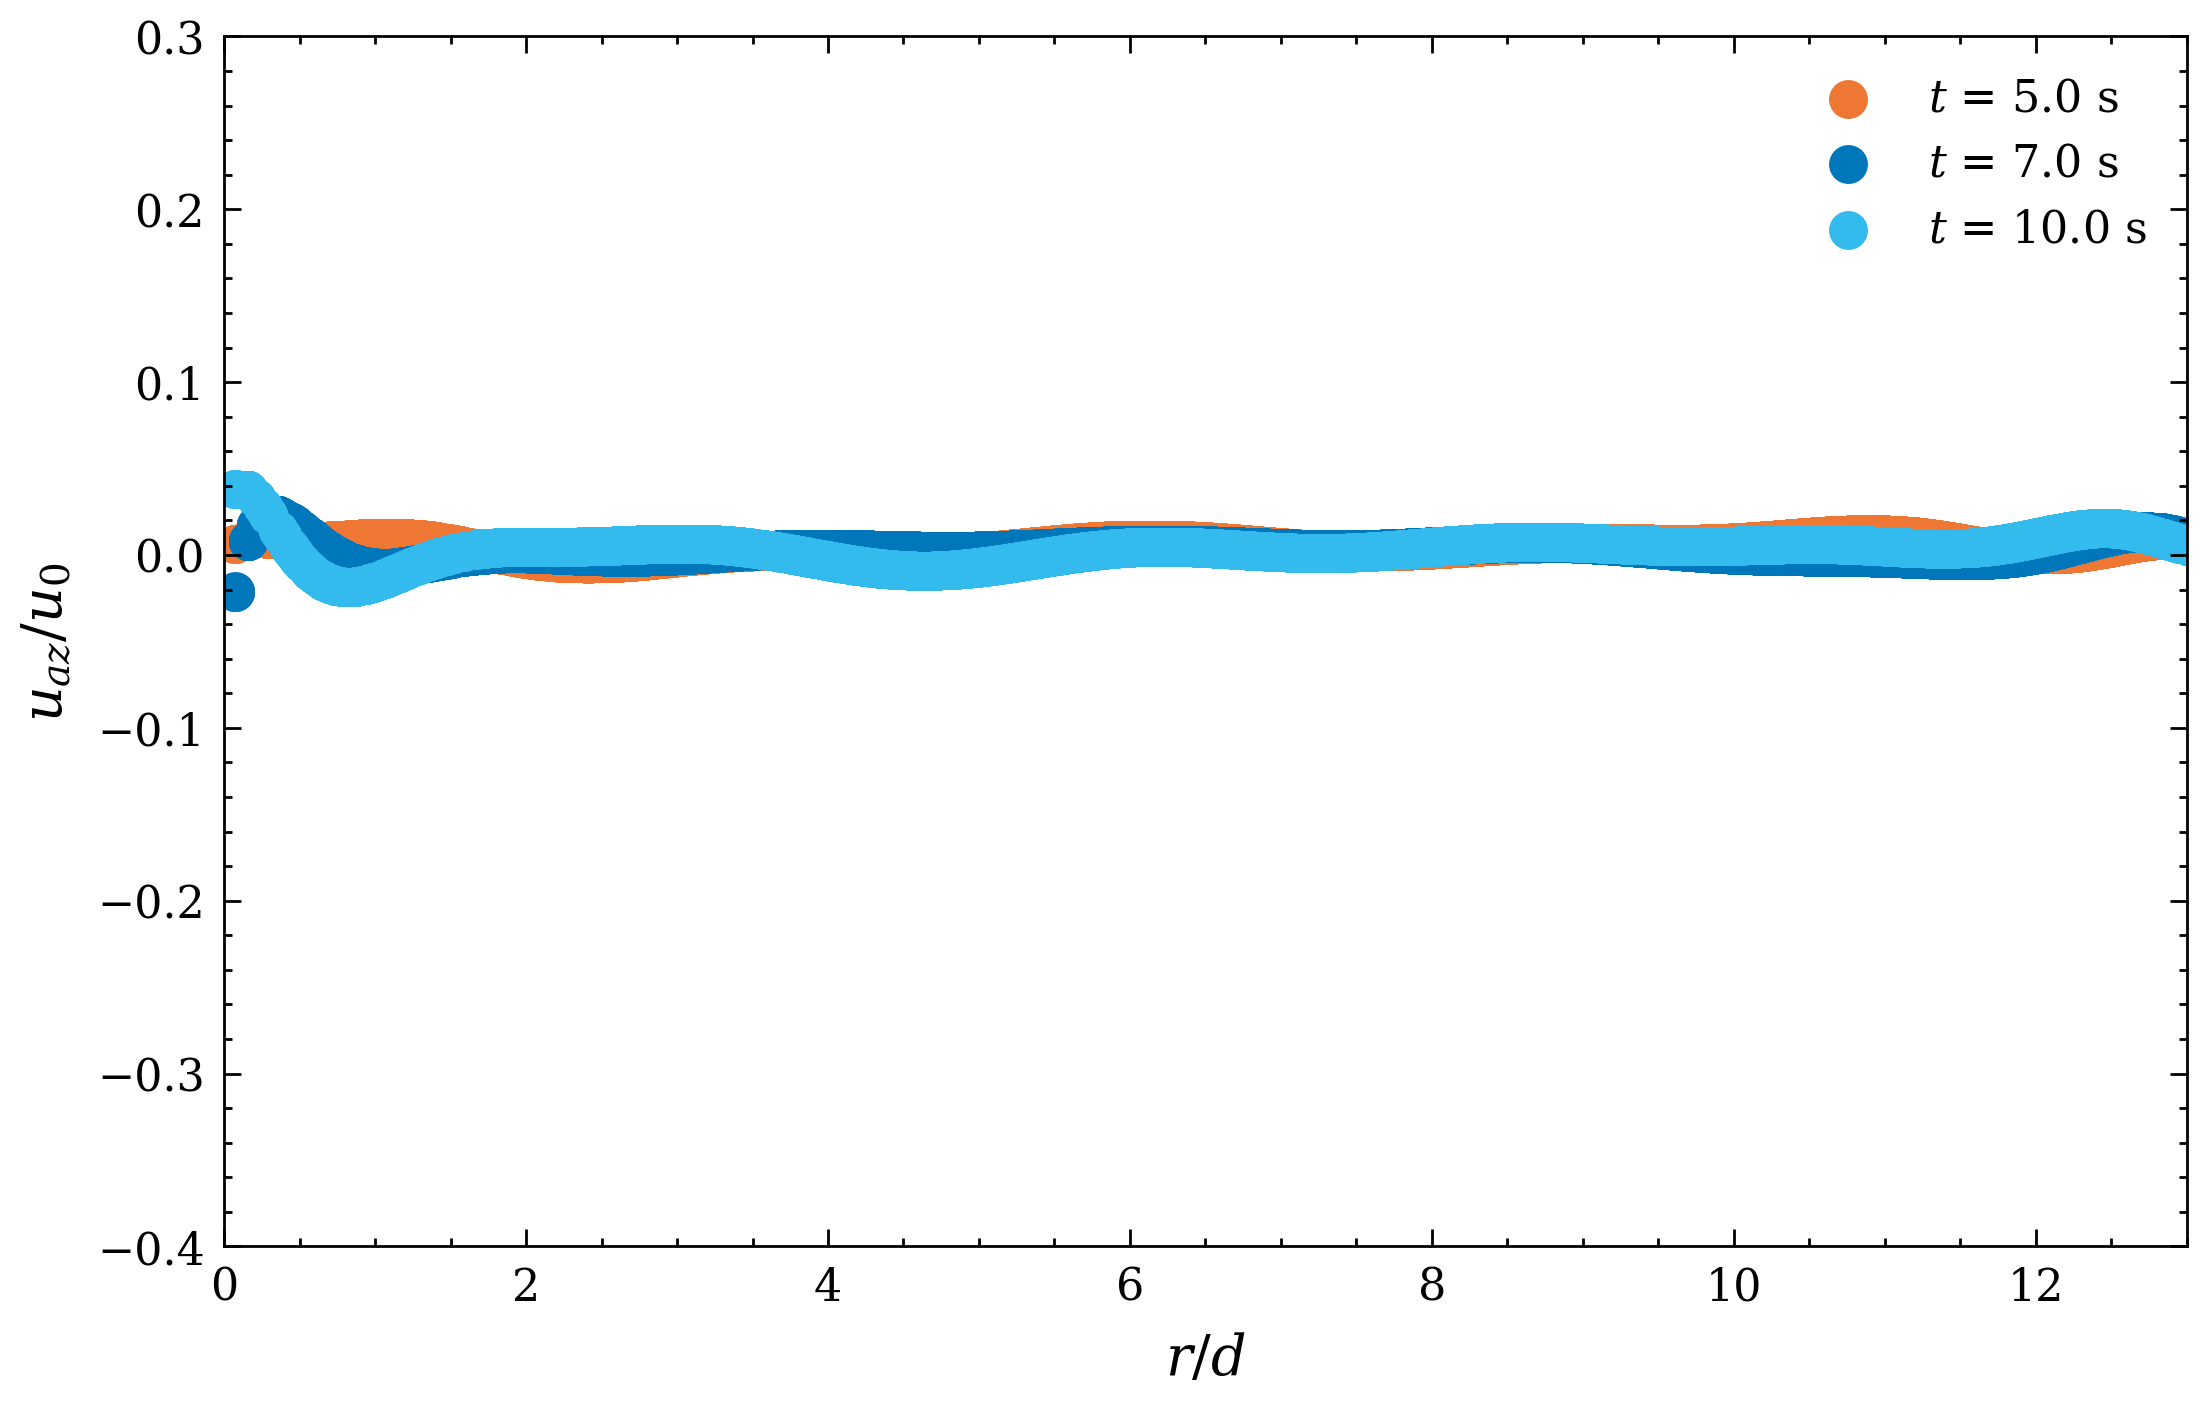

In [138]:
x_c = u.shape[2]/2
y_c = u.shape[1]/2
r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(x_c, y_c, x, y, u[750,:,:], v[750,:,:])
r_arr, theta_arr, U_rBins, U_azBins = oj.binCylindrical(r, theta, U_r, U_az, thetaBins=30, rBins=30)
inds = (r.flatten()).argsort()
r2 = (r.flatten())[inds]
U_az2 = (U_az.flatten())[inds]
p = np.poly1d(np.polyfit(r2, U_az2, 11))(r2)
max = np.argmax(p)

print('inds shape', inds.shape)
print('p shape', p.shape)
print('r2 shape', r2.shape)
print('U_az2 shape', U_az2.shape)

d=0.05
fig, ax = plt.subplots(1, figsize=(5.5, 3.5), dpi = 400)
frames = [750, 1020, 1470]
times = [750/150, 1050/150, 1500/150]

for i in range(len(frames)):
    r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[frames[i],:,:], v[frames[i],:,:])
    r_arr, theta_arr, U_rBins, U_azBins = oj.binCylindrical(r, theta, U_r, U_az, thetaBins=30, rBins=100)
    inds = (r.flatten()).argsort()
    r2 = (r.flatten())[inds]
    U_r2 = (U_r.flatten())[inds]
    pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
    U_az2 = (U_az.flatten())[inds]
    paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)


# ax.plot(r_arr, np.mean(U_rBins, axis=1), label=r'$u_{r}$', color='b')
# ax.scatter(r/d, U_az, color='c', alpha=0.5, edgecolors="k")
# ax.plot(r2/d, p, color='orange')
# ax.plot(r2/d, pr, color='b')
    ax.scatter(r2*0.1, paz, label=fr'$t$ = {times[i]} s')
ax.set_ylim(-0.4, 0.3)
ax.set_xlim(0, 13)
ax.set_xlabel('$r/d$')
ax.set_ylabel(r'$u_{az}/u_{0}$')
ax.legend(fontsize=8)



C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\1446702206.py:24: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\1446702206.py:26: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\1446702206.py:24: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\1446702206.py:26: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\1446702206.py:24: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp

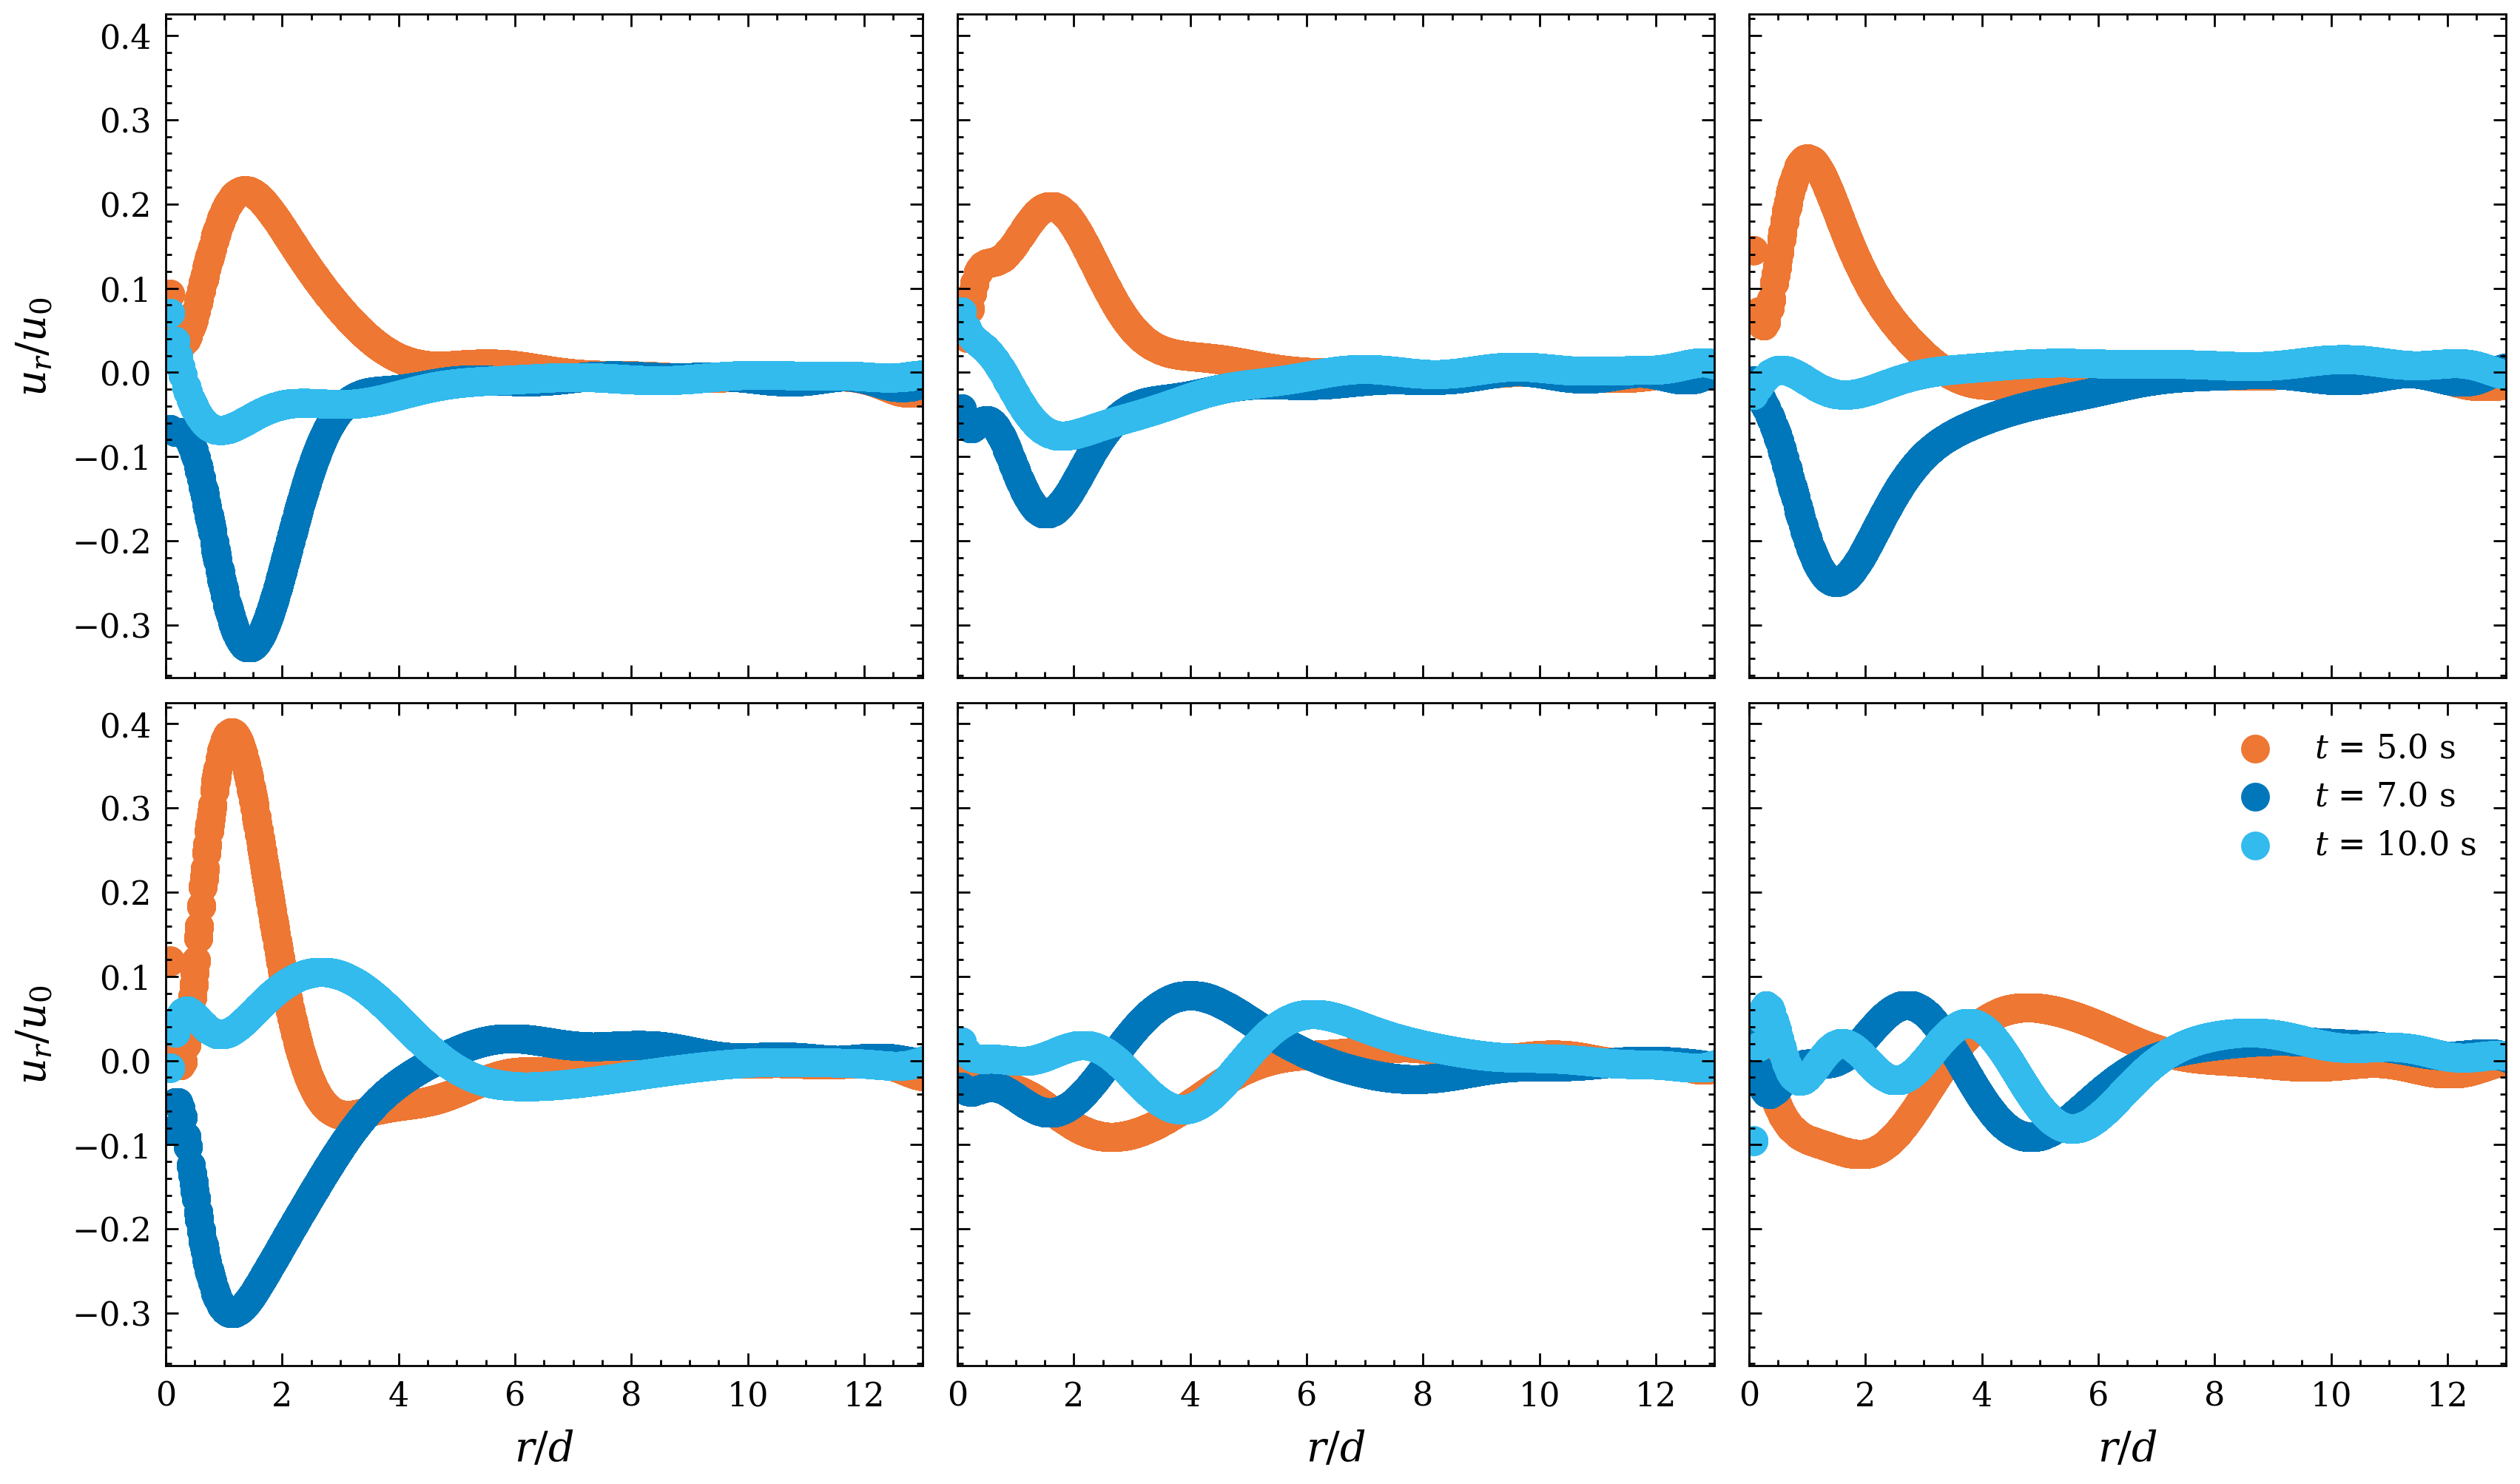

In [139]:
index = 0
rpms = [1, 2, 3, 6, 9, 12]

Eks = [0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

fig, axs = plt.subplots(2, 3,sharex=True, sharey=True, figsize=(8.5, 5))
for i in range(2):
    for j in range(3):

        vels = h5file['3D0']['U100']['L100'][f'RPM{str(rpms[index])}']
        u = vels[:,:,:,0]
        v = vels[:,:,:,1]
        # u, v = oj.scaleVelNozzle(u, v, 150) #make suer to change this for the wide fov data


        for frame in range(len(frames)):
            # colorGen = cmap1(int(frame) / 540)
            ax = axs[i, j]
            r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[frames[frame],:,:], v[frames[frame],:,:])
            r_arr, theta_arr, U_rBins, U_azBins = oj.binCylindrical(r, theta, U_r, U_az, thetaBins=30, rBins=100)
            inds = (r.flatten()).argsort()
            r2 = (r.flatten())[inds]
            U_r2 = (U_r.flatten())[inds]
            pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
            U_az2 = (U_az.flatten())[inds]
            paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
            ax.scatter(r2*0.1, pr, label=fr'$t$ = {times[frame]} s')
            ax.set_xlim(0, 13)
            # ax.set_ylim(-0.4, 0.3)
        index += 1

axs[0, 0].set_ylabel(r'$u_{r}/u_{0}$')
axs[1, 0].set_ylabel(r'$u_{r}/u_{0}$')
axs[1, 0].set_xlabel(r'$r/d$')
axs[1, 1].set_xlabel(r'$r/d$')
axs[1, 2].set_xlabel(r'$r/d$')
axs[1, 2].legend(fontsize=8)
plt.legend(fontsize=8)
plt.show()

Mean and peak plots

C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\3855910762.py:22: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\3855910762.py:22: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\3855910762.py:22: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\3855910762.py:22: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\3855910762.py:22: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_24252\3855910762.py:22: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2

Text(0, 0.5, 'radial location')

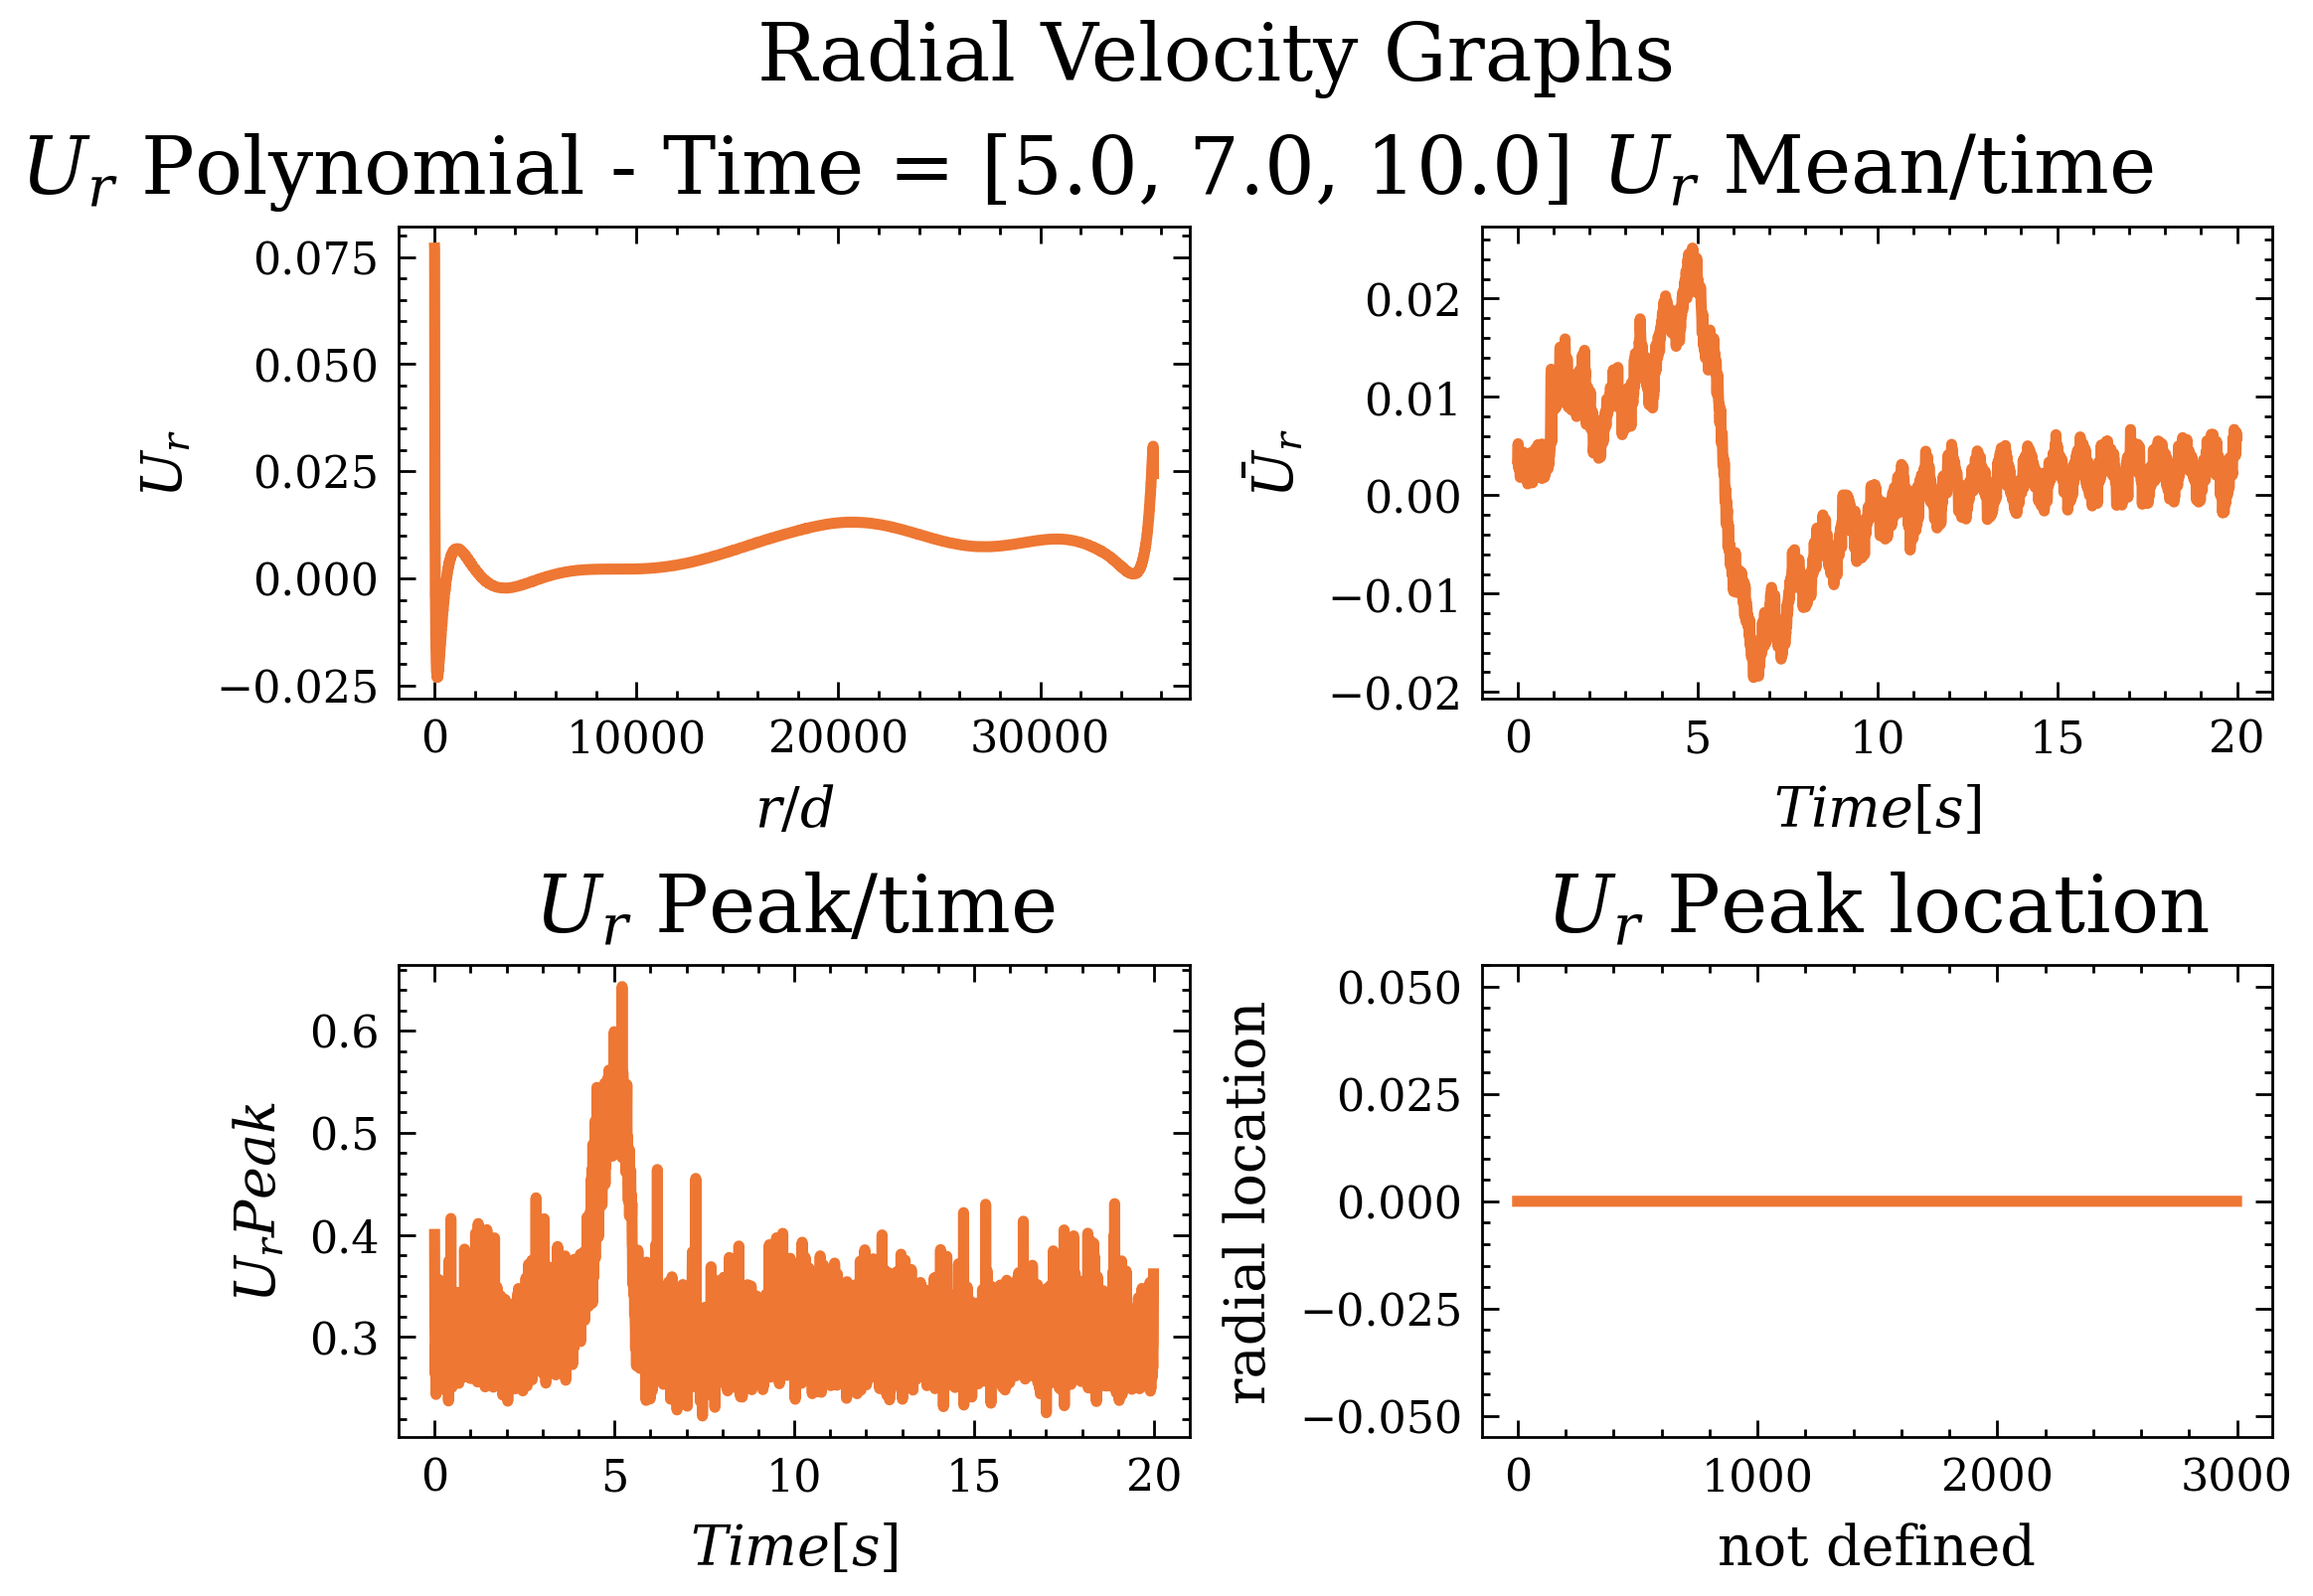

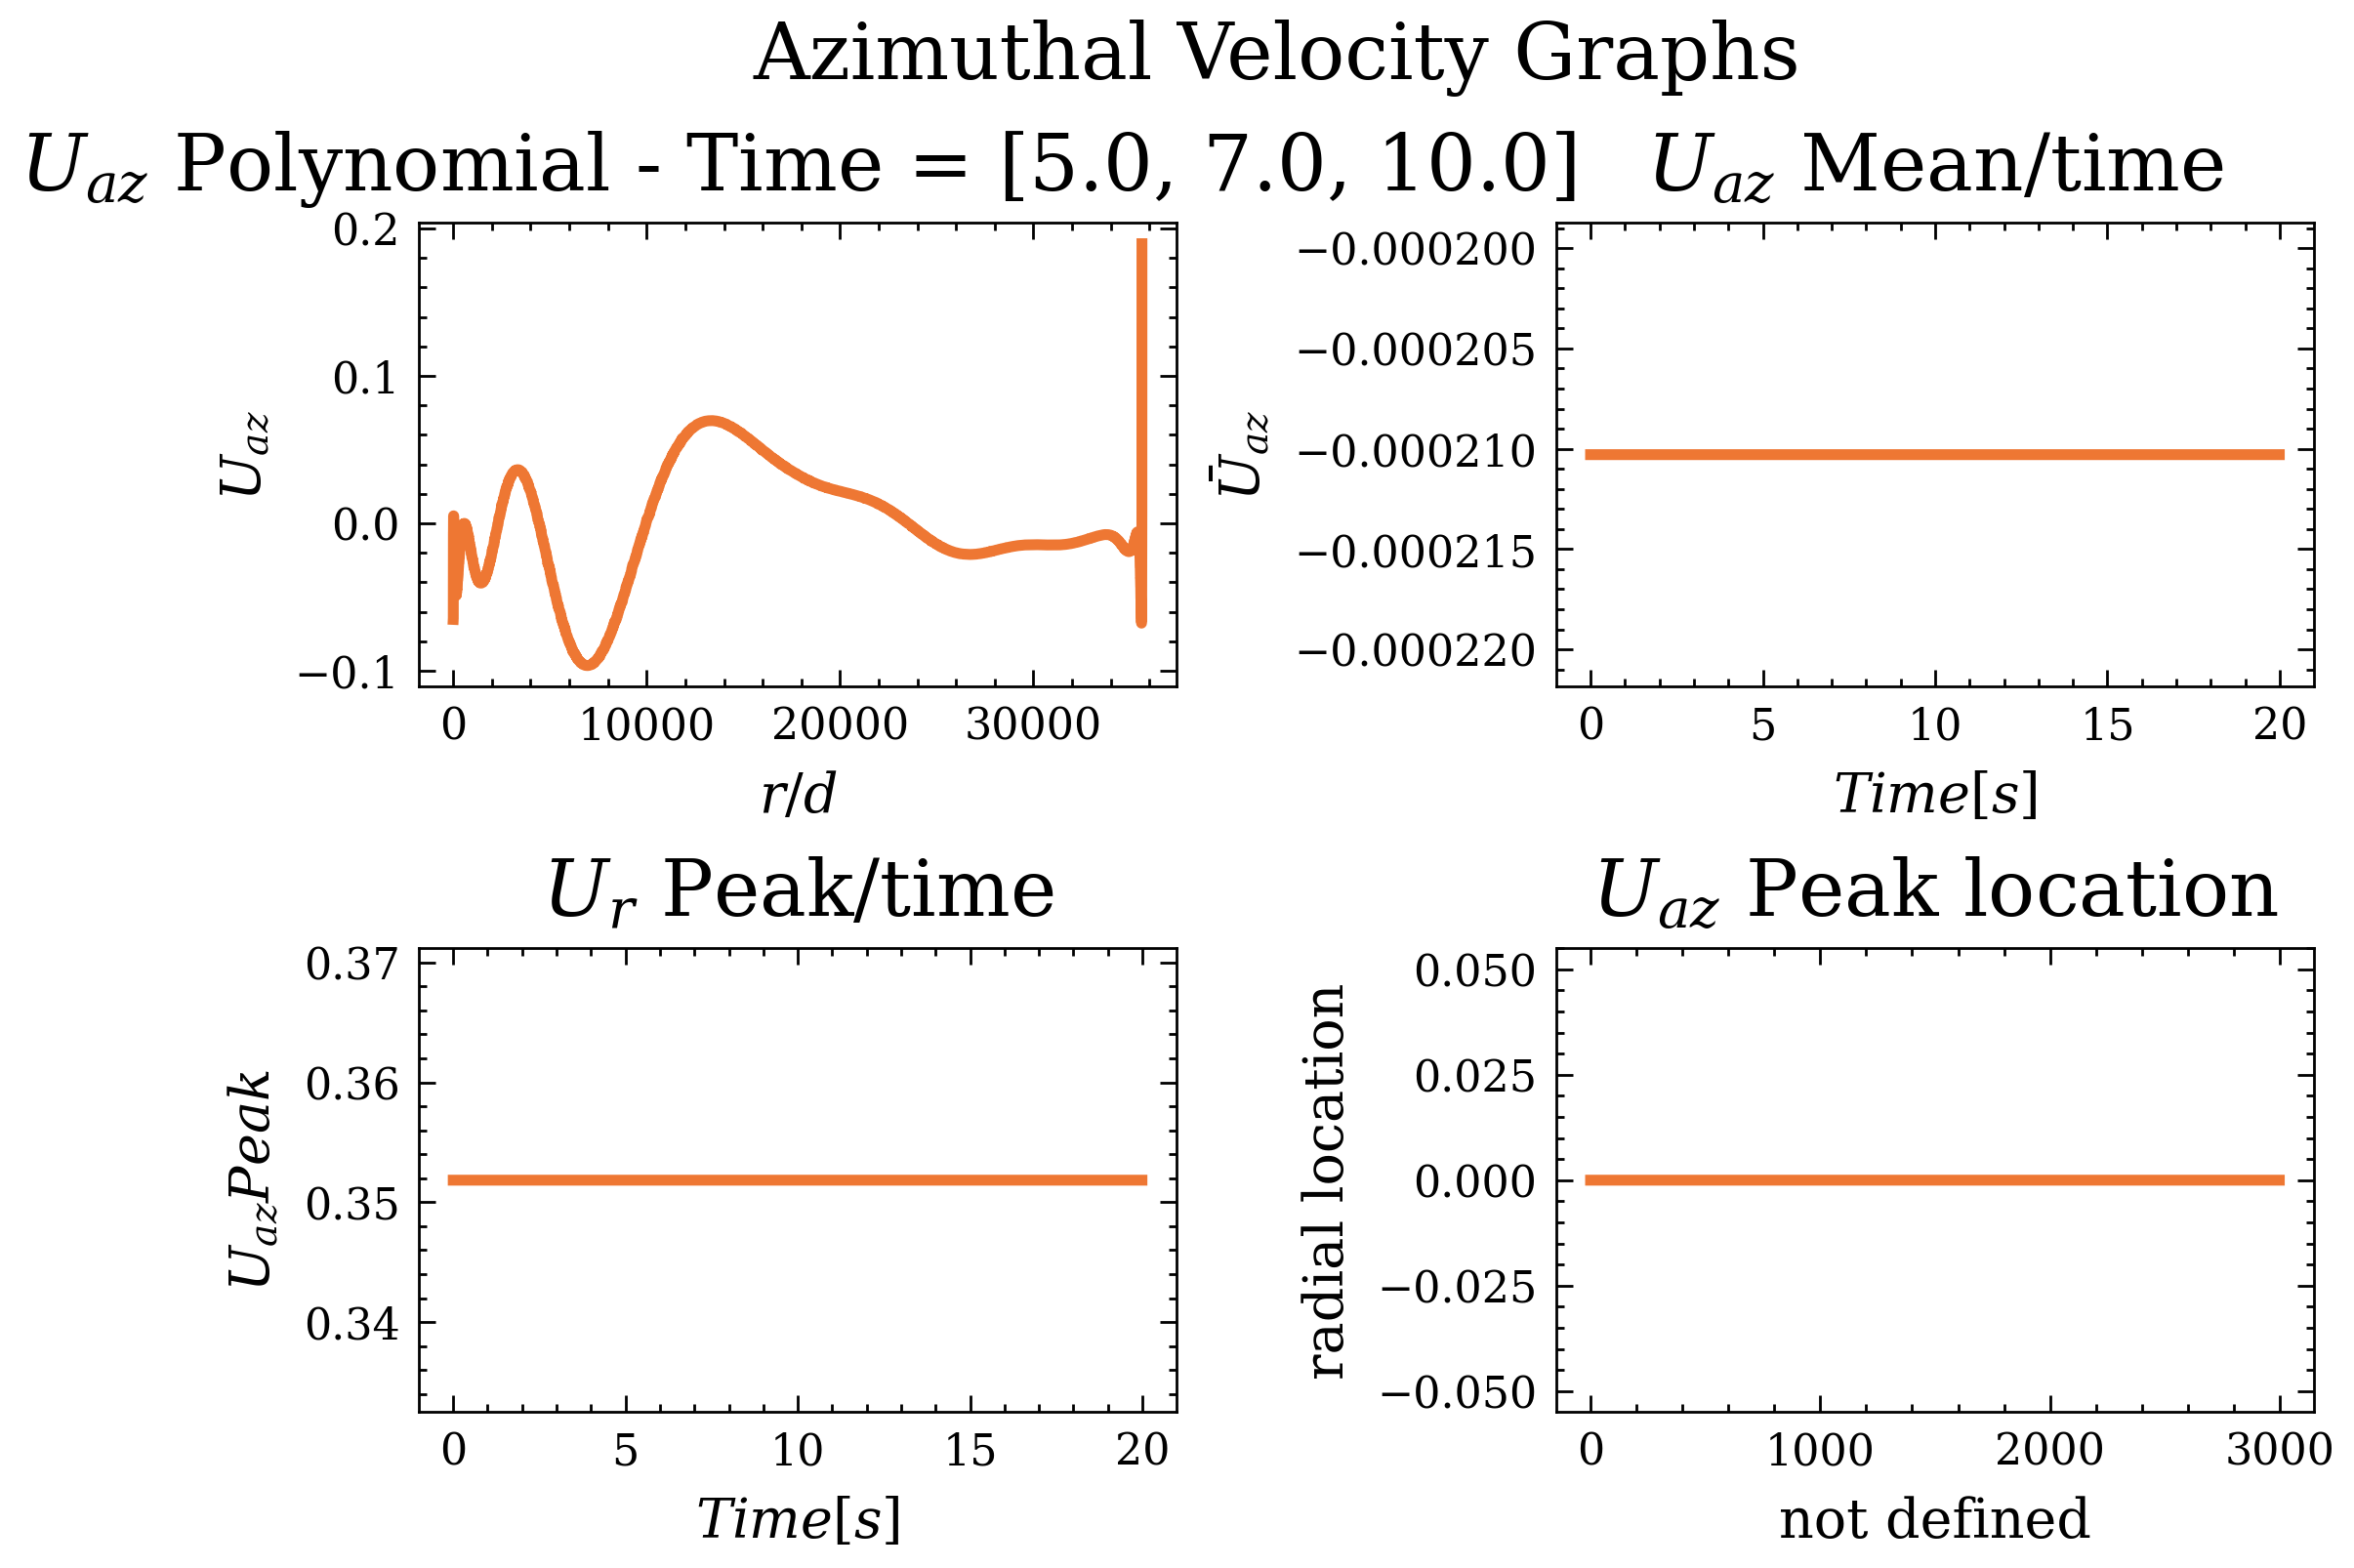

In [144]:
h5file = h5py.File('E:/H5/3D0HLSFine.h5', 'r')
vels = h5file['3D0']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])
time = oj.frames_to_seconds(u, v, 150)
frames0 = [750, 1020, 1470]

radial_Position = np.zeros(u.shape[0])
U_r_Mean = np.zeros(u.shape[0])
U_r_Peak = np.zeros(u.shape[0])
U_az_Mean = np.zeros(u.shape[0])
U_az_Peak = np.zeros(u.shape[0])

for i in range(u.shape[0]):
# for i in range(10): # for testing
    r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[i,:,:], v[i,:,:])
    inds = (r.flatten()).argsort()
    r2 = (r.flatten())[inds]
    U_r2 = (U_r.flatten())[inds]
    pr = np.poly1d(np.polyfit(r2, U_r2, 11))(r2) #This turns the graph into a polynomial line
    paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
    # max = np.argmax(U_az2)
    max = np.argmax(p)
    U_r_Mean[i] = np.mean(U_r2)
    U_r_Peak[i] = np.max(U_r2)
    U_az_Mean[i] = np.mean(U_az2)
    U_az_Peak[i] = np.max(U_az2)
    radial_Position[i] = max


f5, ax = plt.subplots(2, 2)
plt.suptitle("Radial Velocity Graphs")
# ax[0,0].plot(U_r2)
ax[0,0].plot(pr)
ax[0,0].set_title(r"$U_{r}$ Polynomial" + f" - Time = {times}")
ax[0,0].set_xlabel("$r/d$")
ax[0,0].set_ylabel(r"$U_{r}$")
ax[0,1].plot(time, U_r_Mean)
ax[0,1].set_title(r"$U_{r}$ Mean/time")
ax[0,1].set_xlabel("$Time [s]$")
ax[0,1].set_ylabel(r"$\bar{U}_{r}$")
ax[1,0].plot(time, U_r_Peak)
ax[1,0].set_title(r"$U_{r}$ Peak/time")
ax[1,0].set_xlabel("$Time [s]$")
ax[1,0].set_ylabel(r"$U_{r} Peak$")
ax[1,1].plot(radial_Position)
ax[1,1].set_title(r"$U_{r}$ Peak location")
ax[1,1].set_xlabel("not defined")
ax[1,1].set_ylabel("radial location")


f6, ax = plt.subplots(2, 2)
plt.suptitle("Azimuthal Velocity Graphs")
# ax[0,0].plot(U_r2)
ax[0,0].plot(paz)
ax[0,0].set_title(r"$U_{az}$ Polynomial" + f" - Time = {times}")
ax[0,0].set_xlabel("$r/d$")
ax[0,0].set_ylabel(r"$U_{az}$")
ax[0,1].plot(time, U_az_Mean)
ax[0,1].set_title(r"$U_{az}$ Mean/time")
ax[0,1].set_xlabel("$Time [s]$")
ax[0,1].set_ylabel(r"$\bar{U}_{az}$")
ax[1,0].plot(time, U_az_Peak)
ax[1,0].set_title(r"$U_{r}$ Peak/time")
ax[1,0].set_xlabel("$Time [s]$")
ax[1,0].set_ylabel(r"$U_{az} Peak$")
ax[1,1].plot(radial_Position)
ax[1,1].set_title(r"$U_{az}$ Peak location")
ax[1,1].set_xlabel("not defined")
ax[1,1].set_ylabel("radial location")